In [14]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')

import numpy as np
import sklearn.metrics as metrics
import torch
import pickle
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from eb_dataset import EB_DS, load_dataset

import pandas as pd
import warnings

# import tonic
import numpy as np

In [2]:
# Suppress specific warning
warnings.filterwarnings("ignore", category=UserWarning, module='torch.nn.parallel.scatter_gather')
num_points = 1000
ds = {}
# ds['NMN'], _ , __ = load_dataset(tonic_name='NMNIST', tonic_train_split=True, tonic_path='/shareds/',
#                                                      n_samples=num_points, do_shuffle=False)
ds['D1'], labels, _ = load_dataset(base_path='/shareds/eb_datasets/20240407/train/', n_samples=num_points)
ds['D2'], labels, _ = load_dataset(base_path='/shareds/eb_datasets/20240503/train/', n_samples=num_points)

loading /shareds/eb_datasets/20240407/train/events.pkl...
/shareds/eb_datasets/20240407/train/labels.pkl
loading /shareds/eb_datasets/20240503/train/events.pkl...
/shareds/eb_datasets/20240503/train/labels.pkl


In [3]:
# %matplotlib notebook
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def filter_by_interval_and_polarity(d,tmin,tmax,p):
    return np.logical_and(np.logical_and(d[:,0]>=tmin, d[:,0]<=tmax), np.abs(d[:,-1]-p)<1e-6)
    

In [5]:
tparams = {'NMN': [50,60,80],
          'D1': [100.,140, 140],
          'D2': [100.,140, 140],
          }
dd = {'NMN': 23,
          'D1': 8,
          'D2': 8,
          }

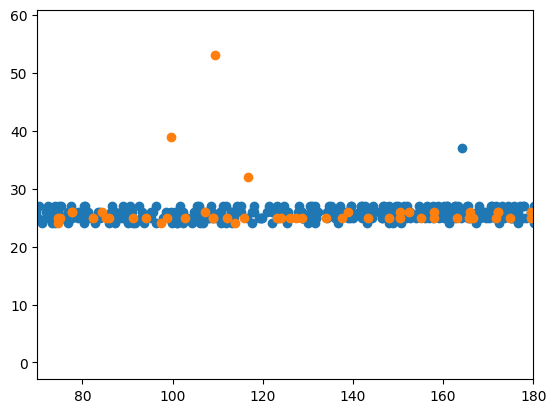

In [6]:
eps = 1e-9
for this_ds in ds:

#     f= plt.figure(figsize=(7,3.5))

#     for ii, uu in enumerate([4568, 10098]):
    for ii, uu in enumerate([4568]):
        tmin,tmax,tmaxshow = tparams[this_ds]
    # for uu in range(9000,9005):

        d = ds[this_ds][uu]
        iip = filter_by_interval_and_polarity(d,tmin,tmax,0)
        iin = filter_by_interval_and_polarity(d,tmin,tmax,1)

        plt.plot(d[:,0],d[:,2],'o')
        plt.xlim([70,180])

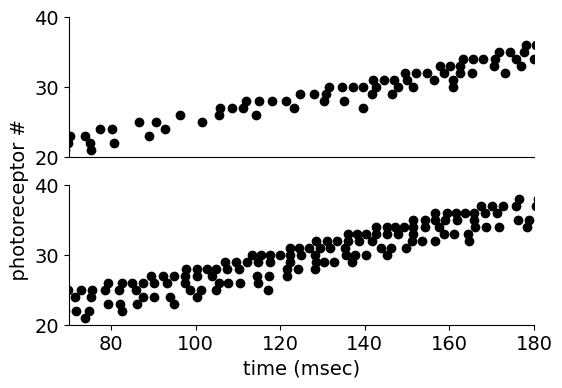

In [17]:
eps = 1e-9
this_ds = 'D1'
plt.figure(1,figsize=(6,4))
plt.rcParams.update({'font.size': 14})

plt.subplot(2,1,1)

#     f= plt.figure(figsize=(7,3.5))

#     for ii, uu in enumerate([4568, 10098]):
for ii, uu in enumerate([4568,4569]):
    plt.subplot(2,1,ii+1)
    plt.rcParams.update({'font.size': 14})

    ax = plt.gca()
    tmin,tmax,tmaxshow = tparams[this_ds]
# for uu in range(9000,9005):
    d = ds[this_ds][uu]
    iip = filter_by_interval_and_polarity(d,tmin,tmax,0)
    iin = filter_by_interval_and_polarity(d,tmin,tmax,1)
    dd = d[:,2]==27
    t = d[dd,0]
    x = d[dd,1]
    interval = np.logical_and(t > 65, t< 190)

    t = t[interval]
    x = x[interval] 
    
    plt.plot(t,x,'ko')
    plt.xlim([70,180])
    plt.ylim([20,40])

    # --- save Fig 3 panel A plot data ---
    additional_info = ["top", "bottom"][ii]

    x_col_name = "time_msec"
    y_col_name = "photoreceptor_num"
    err_col_name = None

    df_plot_data = pd.DataFrame({
        x_col_name: t,
        y_col_name: x,
    })

    cols_to_save = [x_col_name, y_col_name]
    if err_col_name is not None:
        cols_to_save.append(err_col_name)

    df_plot_data[cols_to_save].to_csv(
        f"fig3panelA_{additional_info}.csv",
        index=False
    )
    # --- end save ---

    
#     plt.yticks(np.arange(20,41))
    ax.spines[['right', 'top']].set_visible(False)
plt.subplot(2,1,1)
plt.xticks([])
plt.subplot(2,1,2)
plt.xlabel('time (msec)', fontdict={'size':14})
plt.ylabel('                  photoreceptor #')
plt.savefig('fig3panelA_proto.svg',format='svg')
